# 6. Hyperparameter Experiments — FashionMNIST MLP

Phần của **Thành viên 6**:

 Xây dựng baseline.
 Thử learning rate, batch size, optimizer và hidden layers.
 Huấn luyện lại từng cấu hình từ đầu.
 Đánh giá trên cùng tập test.
 So sánh Test Loss, Test Accuracy và thời gian.
 Chọn cấu hình tốt nhất.

> Mỗi thí nghiệm chỉ thay đổi một yếu tố chính so với baseline.


In [30]:
from pathlib import Path
import copy
import csv
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from data import create_dataloaders
from model import NeuralNetwork


def find_repo_root(start):
    start = Path(start).resolve()

    for current in [start, *start.parents]:
        if (current / "Practice_1").is_dir():
            return current

    raise FileNotFoundError(
        "Không tìm thấy thư mục gốc chứa Practice_1."
    )


REPO_ROOT = find_repo_root(Path.cwd())
PRACTICE_DIR = REPO_ROOT / "Practice_1"
SRC_DIR = PRACTICE_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data import create_dataloaders

DATA_DIR = REPO_ROOT / "data"
FIGURE_DIR = PRACTICE_DIR / "figures"
MODEL_DIR = PRACTICE_DIR / "models"
EXPERIMENT_DIR = PRACTICE_DIR / "experiments"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Repository root:", REPO_ROOT)
print("Device:", device)


Repository root: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2
Device: cpu


## 6.1. Reproducibility and common settings

Tất cả thí nghiệm dùng cùng seed và cùng số epoch để so sánh công bằng.


In [31]:
SEED = 42
EPOCHS = 10


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

print("Seed:", SEED)
print("Epochs per experiment:", EPOCHS)


Seed: 42
Epochs per experiment: 10


## 6.2. Configurable MLP

Baseline tương đương kiến trúc của TV3:

`784 → 128 → 64 → 10`


In [32]:
class ConfigurableMLP(nn.Module):
    def __init__(self, hidden_sizes=(128, 64)):
        super().__init__()

        layers = [nn.Flatten()]
        input_size = 28 * 28

        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(input_size, hidden_size),
                nn.ReLU(),
            ])
            input_size = hidden_size

        layers.append(nn.Linear(input_size, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


dummy_model = ConfigurableMLP((128, 64))
dummy_input = torch.randn(64, 1, 28, 28)

with torch.no_grad():
    dummy_output = dummy_model(dummy_input)

print(dummy_model)
print("Output shape:", dummy_output.shape)
assert dummy_output.shape == (64, 10)


ConfigurableMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)
Output shape: torch.Size([64, 10])


## 6.3. Experiment configurations

| Experiment | Batch | Learning rate | Optimizer | Hidden layers |
|---|---:|---:|---|---|
| Baseline | 64 | 0.001 | Adam | 128–64 |
| Lower LR | 64 | 0.0005 | Adam | 128–64 |
| Higher LR | 64 | 0.005 | Adam | 128–64 |
| Smaller Batch | 32 | 0.001 | Adam | 128–64 |
| SGD | 64 | 0.01 | SGD + momentum | 128–64 |
| Wider Network | 64 | 0.001 | Adam | 256–128 |


In [33]:
EXPERIMENTS = [
    {
        "name": "Baseline",
        "batch_size": 64,
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "hidden_sizes": (128, 64),
    },
    {
        "name": "Lower LR",
        "batch_size": 64,
        "learning_rate": 0.0005,
        "optimizer": "Adam",
        "hidden_sizes": (128, 64),
    },
    {
        "name": "Higher LR",
        "batch_size": 64,
        "learning_rate": 0.005,
        "optimizer": "Adam",
        "hidden_sizes": (128, 64),
    },
    {
        "name": "Smaller Batch",
        "batch_size": 32,
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "hidden_sizes": (128, 64),
    },
    {
        "name": "SGD",
        "batch_size": 64,
        "learning_rate": 0.01,
        "optimizer": "SGD",
        "momentum": 0.9,
        "hidden_sizes": (128, 64),
    },
    {
        "name": "Wider Network",
        "batch_size": 64,
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "hidden_sizes": (256, 128),
    },
]

for experiment in EXPERIMENTS:
    print(experiment)


{'name': 'Baseline', 'batch_size': 64, 'learning_rate': 0.001, 'optimizer': 'Adam', 'hidden_sizes': (128, 64)}
{'name': 'Lower LR', 'batch_size': 64, 'learning_rate': 0.0005, 'optimizer': 'Adam', 'hidden_sizes': (128, 64)}
{'name': 'Higher LR', 'batch_size': 64, 'learning_rate': 0.005, 'optimizer': 'Adam', 'hidden_sizes': (128, 64)}
{'name': 'Smaller Batch', 'batch_size': 32, 'learning_rate': 0.001, 'optimizer': 'Adam', 'hidden_sizes': (128, 64)}
{'name': 'SGD', 'batch_size': 64, 'learning_rate': 0.01, 'optimizer': 'SGD', 'momentum': 0.9, 'hidden_sizes': (128, 64)}
{'name': 'Wider Network', 'batch_size': 64, 'learning_rate': 0.001, 'optimizer': 'Adam', 'hidden_sizes': (256, 128)}


## 6.4. Training and evaluation functions


In [34]:
def build_optimizer(model, config):
    if config["optimizer"] == "Adam":
        return optim.Adam(
            model.parameters(),
            lr=config["learning_rate"],
        )

    if config["optimizer"] == "SGD":
        return optim.SGD(
            model.parameters(),
            lr=config["learning_rate"],
            momentum=config.get("momentum", 0.0),
        )

    raise ValueError("Unsupported optimizer")


def train_model(
    model,
    train_loader,
    optimizer,
    device,
    epochs,
):
    criterion = nn.CrossEntropyLoss()
    loss_history = []
    accuracy_history = []

    start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            batch_size = labels.size(0)

            running_loss += loss.item() * batch_size
            correct += (
                logits.argmax(dim=1) == labels
            ).sum().item()
            total += batch_size

        epoch_loss = running_loss / total
        epoch_accuracy = 100.0 * correct / total

        loss_history.append(epoch_loss)
        accuracy_history.append(epoch_accuracy)

        print(
            f"Epoch [{epoch}/{epochs}] "
            f"- Loss: {epoch_loss:.4f} "
            f"- Train Accuracy: {epoch_accuracy:.2f}%"
        )

    training_time = time.perf_counter() - start_time

    return loss_history, accuracy_history, training_time


def evaluate_model(model, test_loader, device):
    model.eval()

    criterion = nn.CrossEntropyLoss(reduction="sum")

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.inference_mode():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)

            total_loss += criterion(
                logits,
                labels,
            ).item()

            predictions = logits.argmax(dim=1)

            total_correct += (
                predictions == labels
            ).sum().item()

            total_samples += labels.size(0)

    return (
        total_loss / total_samples,
        100.0 * total_correct / total_samples,
    )


## 6.5. Run all experiments

Mỗi cấu hình được khởi tạo và huấn luyện lại từ đầu. Trên CPU, phần này có thể mất vài phút.


In [35]:
results = []
histories = {}

best_accuracy = -1.0
best_state_dict = None
best_config = None

for index, config in enumerate(EXPERIMENTS, start=1):
    print("\n" + "=" * 70)
    print(
        f"Experiment {index}/{len(EXPERIMENTS)}: "
        f"{config['name']}"
    )
    print("=" * 70)

    set_seed(SEED)

    (
        train_dataset,
        test_dataset,
        train_loader,
        test_loader,
    ) = create_dataloaders(
        data_dir=DATA_DIR,
        batch_size=config["batch_size"],
    )

    model = ConfigurableMLP(
        hidden_sizes=config["hidden_sizes"]
    ).to(device)

    optimizer = build_optimizer(model, config)

    (
        loss_history,
        accuracy_history,
        training_time,
    ) = train_model(
        model=model,
        train_loader=train_loader,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
    )

    test_loss, test_accuracy = evaluate_model(
        model=model,
        test_loader=test_loader,
        device=device,
    )

    result = {
        "experiment": config["name"],
        "batch_size": config["batch_size"],
        "learning_rate": config["learning_rate"],
        "optimizer": config["optimizer"],
        "hidden_sizes": "-".join(
            map(str, config["hidden_sizes"])
        ),
        "epochs": EPOCHS,
        "final_train_loss": loss_history[-1],
        "final_train_accuracy":
            accuracy_history[-1],
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "training_time_seconds": training_time,
    }

    results.append(result)

    histories[config["name"]] = loss_history

    print(f"Test Loss    : {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.2f}%")
    print(f"Training Time: {training_time:.2f}s")

    if test_accuracy > best_accuracy:
        best_accuracy = test_accuracy
        best_state_dict = copy.deepcopy(
            model.state_dict()
        )
        best_config = copy.deepcopy(config)



Experiment 1/6: Baseline


Epoch [1/10] - Loss: 0.5616 - Train Accuracy: 80.07%
Epoch [2/10] - Loss: 0.3890 - Train Accuracy: 86.07%
Epoch [3/10] - Loss: 0.3487 - Train Accuracy: 87.39%
Epoch [4/10] - Loss: 0.3225 - Train Accuracy: 88.21%
Epoch [5/10] - Loss: 0.3087 - Train Accuracy: 88.55%
Epoch [6/10] - Loss: 0.2889 - Train Accuracy: 89.44%
Epoch [7/10] - Loss: 0.2781 - Train Accuracy: 89.63%
Epoch [8/10] - Loss: 0.2662 - Train Accuracy: 90.18%
Epoch [9/10] - Loss: 0.2586 - Train Accuracy: 90.32%
Epoch [10/10] - Loss: 0.2458 - Train Accuracy: 90.84%
Test Loss    : 0.3380
Test Accuracy: 88.09%
Training Time: 74.94s

Experiment 2/6: Lower LR
Epoch [1/10] - Loss: 0.6181 - Train Accuracy: 78.61%
Epoch [2/10] - Loss: 0.4178 - Train Accuracy: 85.38%
Epoch [3/10] - Loss: 0.3797 - Train Accuracy: 86.51%
Epoch [4/10] - Loss: 0.3496 - Train Accuracy: 87.56%
Epoch [5/10] - Loss: 0.3318 - Train Accuracy: 88.00%
Epoch [6/10] - Loss: 0.3127 - Train Accuracy: 88.77%
Epoch [7/10] - Loss: 0.3009 - Train Accuracy: 88.97%
Epoch 

## 6.6. Comparison table


In [36]:
header = (
    f"{'Experiment':<18}"
    f"{'Batch':>7}"
    f"{'LR':>10}"
    f"{'Optimizer':>11}"
    f"{'Hidden':>12}"
    f"{'Test Loss':>12}"
    f"{'Test Acc':>11}"
    f"{'Time(s)':>10}"
)

print(header)
print("-" * len(header))

for result in results:
    print(
        f"{result['experiment']:<18}"
        f"{result['batch_size']:>7}"
        f"{result['learning_rate']:>10.4f}"
        f"{result['optimizer']:>11}"
        f"{result['hidden_sizes']:>12}"
        f"{result['test_loss']:>12.4f}"
        f"{result['test_accuracy']:>10.2f}%"
        f"{result['training_time_seconds']:>10.2f}"
    )


Experiment          Batch        LR  Optimizer      Hidden   Test Loss   Test Acc   Time(s)
-------------------------------------------------------------------------------------------
Baseline               64    0.0010       Adam      128-64      0.3380     88.09%     74.94
Lower LR               64    0.0005       Adam      128-64      0.3436     87.80%     74.99
Higher LR              64    0.0050       Adam      128-64      0.3719     86.85%     75.99
Smaller Batch          32    0.0010       Adam      128-64      0.3371     88.18%     85.95
SGD                    64    0.0100        SGD      128-64      0.3359     87.90%     70.99
Wider Network          64    0.0010       Adam     256-128      0.3266     88.60%     81.80


## 6.7 Save results to CSV 

In [37]:
RESULTS_PATH = (
    EXPERIMENT_DIR
    / "hyperparameter_results.csv"
)

with RESULTS_PATH.open(
    "w",
    newline="",
    encoding="utf-8",
) as file:
    writer = csv.DictWriter(
        file,
        fieldnames=list(results[0].keys()),
    )

    writer.writeheader()
    writer.writerows(results)

print("Saved:", RESULTS_PATH)


Saved: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\experiments\hyperparameter_results.csv


## 6.8 Test Accuracy comparison 

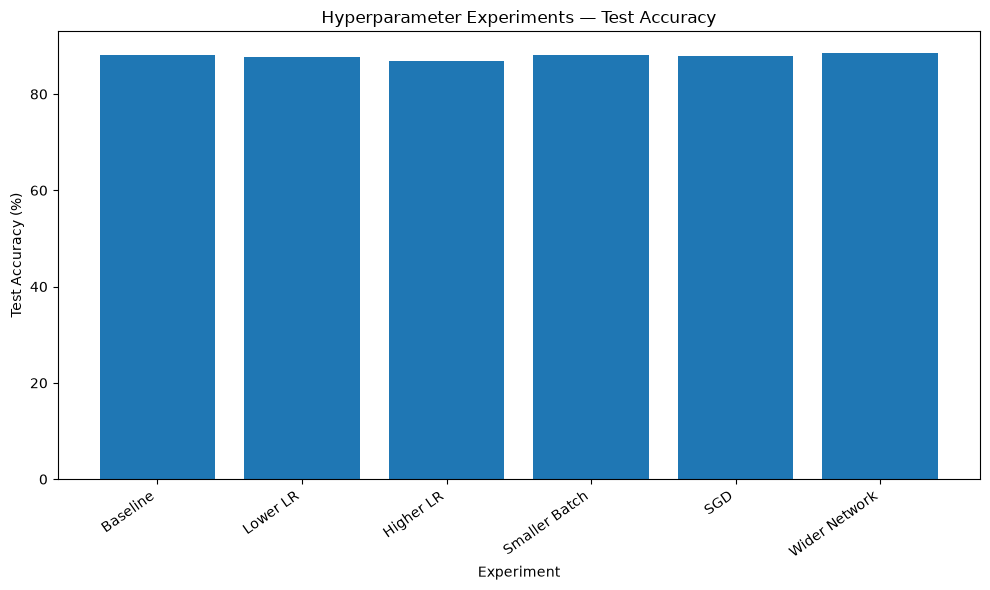

Saved: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures\hyperparameter_test_accuracy.png


In [38]:
ACCURACY_PATH = (
    FIGURE_DIR
    / "hyperparameter_test_accuracy.png"
)

names = [
    result["experiment"]
    for result in results
]

accuracies = [
    result["test_accuracy"]
    for result in results
]

plt.figure(figsize=(10, 6))
plt.bar(names, accuracies)
plt.title("Hyperparameter Experiments — Test Accuracy")
plt.xlabel("Experiment")
plt.ylabel("Test Accuracy (%)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(
    ACCURACY_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", ACCURACY_PATH)


## 6.9 Test loss comparison 

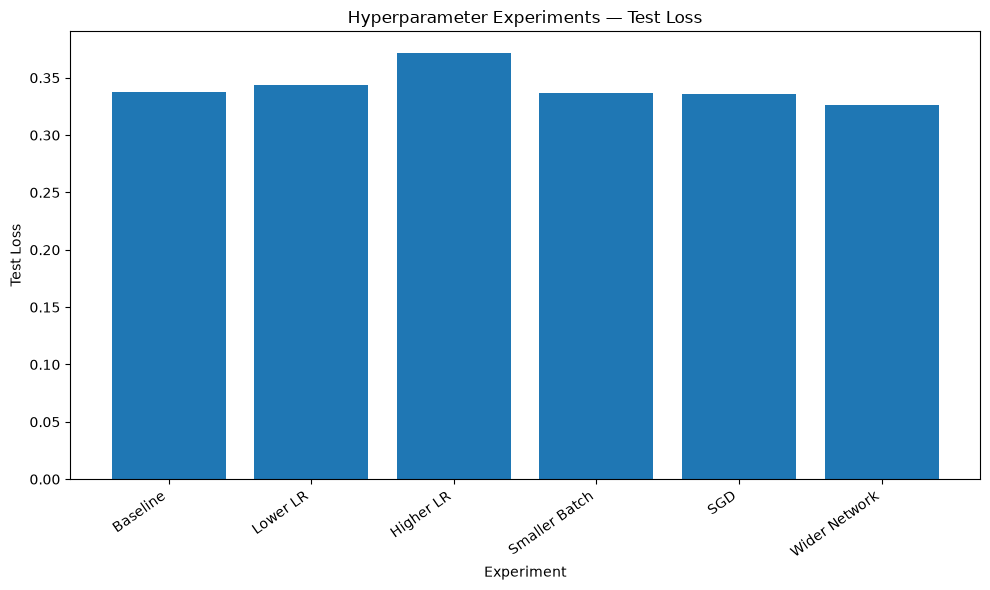

Saved: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures\hyperparameter_test_loss.png


In [39]:
TEST_LOSS_PATH = (
    FIGURE_DIR
    / "hyperparameter_test_loss.png"
)

losses = [
    result["test_loss"]
    for result in results
]

plt.figure(figsize=(10, 6))
plt.bar(names, losses)
plt.title("Hyperparameter Experiments — Test Loss")
plt.xlabel("Experiment")
plt.ylabel("Test Loss")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(
    TEST_LOSS_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", TEST_LOSS_PATH)


## 6.10. Training loss curves


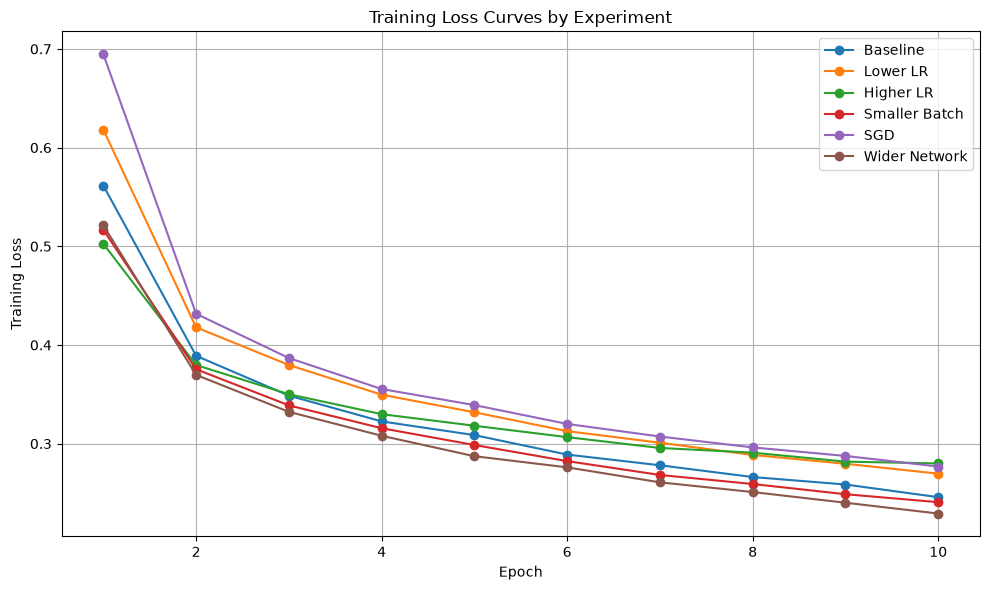

Saved: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures\hyperparameter_loss_curves.png


In [40]:
LOSS_CURVES_PATH = (
    FIGURE_DIR
    / "hyperparameter_loss_curves.png"
)

plt.figure(figsize=(10, 6))

for name, loss_history in histories.items():
    plt.plot(
        range(1, len(loss_history) + 1),
        loss_history,
        marker="o",
        label=name,
    )

plt.title("Training Loss Curves by Experiment")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    LOSS_CURVES_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", LOSS_CURVES_PATH)


## 6.11. Load and evaluate the official TV4 checkpoint

 
Checkpoint này sử dụng kiến trúc MLP:

`784 → 128 → 64 → 10`

 

In [41]:
from pathlib import Path
import hashlib
import torch


TV4_CHECKPOINT_PATH = (
    MODEL_DIR
    / "fashion_mnist_mlp_trained.pth"
)


if not TV4_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        "Không tìm thấy checkpoint chính thức của TV4:\n"
        f"{TV4_CHECKPOINT_PATH}\n\n"
        "Hãy kiểm tra nhánh hiện tại là len-brand và file đã được "
        "commit vào Practice_1/models/."
    )


 
# Tính SHA256 để xác nhận đúng checkpoint
 
def calculate_sha256(file_path: Path) -> str:
    sha256 = hashlib.sha256()

    with file_path.open("rb") as file:
        for chunk in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            sha256.update(chunk)

    return sha256.hexdigest()


tv4_checkpoint_hash = calculate_sha256(
    TV4_CHECKPOINT_PATH
)


 
# Khởi tạo đúng kiến trúc model của TV3
 
tv4_model = NeuralNetwork().to(device)


 
# Load trọng số đã train của TV4
 
tv4_state_dict = torch.load(
    TV4_CHECKPOINT_PATH,
    map_location=device,
    weights_only=True,
)

tv4_model.load_state_dict(
    tv4_state_dict,
    strict=True,
)

tv4_model.eval()


 
# Đánh giá checkpoint TV4 bằng cùng test_loader
 
tv4_test_loss, tv4_test_accuracy = evaluate_model(
    model=tv4_model,
    test_loader=test_loader,
    device=device,
)


 

print("Checkpoint path :", TV4_CHECKPOINT_PATH.resolve())
print(
    "File size       :",
    TV4_CHECKPOINT_PATH.stat().st_size,
    "bytes",
)
print("SHA256          :", tv4_checkpoint_hash)
print(f"Test Loss       : {tv4_test_loss:.4f}")
print(f"Test Accuracy   : {tv4_test_accuracy:.2f}%")

Checkpoint path : D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\models\fashion_mnist_mlp_trained.pth
File size       : 440941 bytes
SHA256          : 32484af011f3a9289e5b8c3cd69442ab147880a9a1a4d48620e1dc16298f09bc
Test Loss       : 0.3415
Test Accuracy   : 88.12%


In [42]:
print("TV4 CHECKPOINT VS TV6 BEST EXPERIMENT")
print("=" * 65)

print(
    f"TV4 official checkpoint : "
    f"Loss = {tv4_test_loss:.4f}, "
    f"Accuracy = {tv4_test_accuracy:.2f}%"
)

print(
    f"TV6 best experiment     : "
    f"Accuracy = {best_accuracy:.2f}%"
)

accuracy_difference = (
    best_accuracy - tv4_test_accuracy
)

print(
    f"Accuracy difference     : "
    f"{accuracy_difference:+.2f}%"
)

if accuracy_difference > 0:
    print(
        "Kết luận: cấu hình tốt nhất của TV6 có "
        "accuracy cao hơn checkpoint TV4."
    )
elif accuracy_difference < 0:
    print(
        "Kết luận: checkpoint TV4 có accuracy "
        "cao hơn cấu hình tốt nhất của TV6."
    )
else:
    print(
        "Kết luận: hai kết quả có accuracy bằng nhau."
    )

TV4 CHECKPOINT VS TV6 BEST EXPERIMENT
TV4 official checkpoint : Loss = 0.3415, Accuracy = 88.12%
TV6 best experiment     : Accuracy = 88.60%
Accuracy difference     : +0.48%
Kết luận: cấu hình tốt nhất của TV6 có accuracy cao hơn checkpoint TV4.


In [44]:
best_result = max(
    results,
    key=lambda row: row["test_accuracy"],
)

print("BEST TV6 EXPERIMENT")
print("=" * 55)

print("Experiment       :", best_result["experiment"])
print("Batch size       :", best_result["batch_size"])
print("Learning rate    :", best_result["learning_rate"])
print("Optimizer        :", best_result["optimizer"])
print("Hidden layers    :", best_result["hidden_sizes"])
print("Epochs           :", best_result["epochs"])
print(f"Test Loss        : {best_result['test_loss']:.4f}")
print(f"Test Accuracy    : {best_result['test_accuracy']:.2f}%")
print(
    f"Training time    : "
    f"{best_result['training_time_seconds']:.2f}s"
)

BEST TV6 EXPERIMENT
Experiment       : Wider Network
Batch size       : 64
Learning rate    : 0.001
Optimizer        : Adam
Hidden layers    : 256-128
Epochs           : 10
Test Loss        : 0.3266
Test Accuracy    : 88.60%
Training time    : 81.80s


## 6.12. Result analysis

In [43]:
BEST_TV6_MODEL_PATH = (
    MODEL_DIR
    / "best_hyperparameter_model.pth"
)

torch.save(
    {
        "model_state_dict": best_state_dict,
        "config": best_config,
        "test_accuracy": best_accuracy,
        "seed": SEED,
        "epochs": EPOCHS,
    },
    BEST_TV6_MODEL_PATH,
)

 
print("Experiment    :", best_config["name"])
print("Batch size    :", best_config["batch_size"])
print("Learning rate :", best_config["learning_rate"])
print("Optimizer     :", best_config["optimizer"])
print("Hidden sizes  :", best_config["hidden_sizes"])
print(f"Test Accuracy : {best_accuracy:.2f}%")
print("Saved path    :", BEST_TV6_MODEL_PATH)

Experiment    : Wider Network
Batch size    : 64
Learning rate : 0.001
Optimizer     : Adam
Hidden sizes  : (256, 128)
Test Accuracy : 88.60%
Saved path    : D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\models\best_hyperparameter_model.pth
